In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohankrishnathalla/diabetes-health-indicators-dataset")
print("Dataset path:", path)


RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plotting settings
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")
print(f"Random seed set to: {RANDOM_SEED}")

# Load dataset correctly
df = pd.read_csv(f"{path}/diabetes_dataset.csv")
print(df.shape)
print(df.columns) # Display column names (our features)
print(df.dtypes)
df.head(10) # Display first 10 records

print("Dataset before cleaning:")
for column in df.columns:
    if np.issubdtype(df[column].dtype, np.number):
        print(f"{column:<40} Mean: {df[column].mean():>8.3f} | Median: {df[column].median():>8.3f}")

# Handling Null Values (empty records)
df_null = df.isnull() # bool
total_null = df_null.sum().sum() # count

print(f"Total Before:   {total_null} null") # Summing up null values for each column before handling
print(df.shape)

df_cleaned = df.copy()

# Handling Outliers
exclude_columns = ['family_history_diabetes','hypertension_history','cardiovascular_history','diagnosed_diabetes'] # Categorical columns to exclude (These are True/False binary values)
for col in exclude_columns:
    df_cleaned[col] = df_cleaned[col].clip(0,1) # reassigns any outliers to the closest bounds (0 or 1)

allowed_columns = df_cleaned.select_dtypes(include=[np.number]).columns.difference(exclude_columns) # columns to check for outliers

# Using IQR https://www.kaggle.com/code/aman2626786/outlier-removal-using-iqr-method
# This removes around 16k records from original 100k records
for col in allowed_columns:
    p25 = df_cleaned[col].quantile(0.25)
    p75 = df_cleaned[col].quantile(0.75)
    iqr = p75 - p25
    lower_bound = p25 - 1.5 * iqr
    upper_bound = p75 + 1.5 * iqr
    df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)] # Remove outliers

# Handling duplicate and empty records
df_cleaned = df_cleaned.drop_duplicates().dropna().drop('diabetes_stage', axis=1) # Drop duplicates, empty records, and 'diabetes_stage' column


for column in df_cleaned.columns:
    if df_cleaned[column].isnull().sum() > 0: # Check column datatypes if there exists null values
        if df_cleaned[column].dtype in [np.float64, np.int64]: # Numerical variables
            print(f"{column} contains {df_cleaned[column].isnull().sum()} null values.")
            df_cleaned[column] = df_cleaned[column].fillna(df_cleaned[column].median())
        else:
            df_cleaned[column] = df_cleaned[column].fillna("UNKNOWN") # Categorical variables

cleandf_null = df_cleaned.isnull() # bool

print(f"Total After:    {cleandf_null.sum().sum()} null") # Summing up null values for each column
print(df_cleaned.shape)

print("Dataset after cleaning:")
for column in df_cleaned.columns:
    if np.issubdtype(df_cleaned[column].dtype, np.number):
        print(f"{column:<40} Mean: {df_cleaned[column].mean():>8.3f} | Median: {df_cleaned[column].median():>8.3f}")

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

nominal_columns = ['gender', 'ethnicity', 'employment_status']
ordinal_columns = ['education_level', 'income_level', 'smoking_status']
ordinal_categories = [
    ['No formal', 'Highschool', 'Graduate', 'Postgraduate'],  # education_level
    ['Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High'],  # income_level
    ['Never', 'Former', 'Current']  # smoking_status
]

# One Hot Encoding
df_feature = df_cleaned.copy()
df_feature = pd.get_dummies(df_feature, columns=nominal_columns,drop_first=True,dtype=int)

# Ordinal Encoding
encoder = OrdinalEncoder(categories=ordinal_categories)
df_feature[ordinal_columns] = encoder.fit_transform(df_feature[ordinal_columns])

#df_feature will be used on forward instead of df_clean btw

Dataset path: /Users/tylerguo/.cache/kagglehub/datasets/mohankrishnathalla/diabetes-health-indicators-dataset/versions/1
Libraries imported successfully!
Random seed set to: 42
(100000, 31)
Index(['age', 'gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diabetes_stage', 'diagnosed_diabetes'],
      dtype='object')
age                                     int64
gender                                 object
ethnicity                 

In [24]:
# ==============================
# Correlation with diagnosed_diabetes
# ==============================
strong_corr = {}      # save positively correlated features here
inv_strong_corr = {}  # save negatively correlated features here

target_col = 'diagnosed_diabetes'
features = df_feature.columns.difference([target_col])

for col in features:
    # Only compute correlation for numeric columns
    if np.issubdtype(df_feature[col].dtype, np.number):
        corr_val = df_feature[col].corr(df_feature[target_col])
        if corr_val > 0.3:      # moderate/strong positive correlation
            strong_corr[col] = corr_val
            print(f"Positive correlation - {col}: {corr_val:.3f}")
        elif corr_val < -0.3:   # moderate/strong negative correlation
            inv_strong_corr[col] = corr_val
            print(f"Negative correlation - {col}: {corr_val:.3f}")

# Optional: inspect dictionaries
# print("Strong positive correlations:", strong_corr)
# print("Strong negative correlations:", inv_strong_corr)


# ==============================
# AGE DISTRIBUTION BY DIABETES STATUS
# ==============================

# Create age bins and labels
age_bins = [0, 20, 30, 40, 50, 60, 100]
age_labels = ['≤20', '21-30', '31-40', '41-50', '51-60', '60+']

# Initialize counters
age_no_diabetes = [0, 0, 0, 0, 0, 0]
age_diabetes = [0, 0, 0, 0, 0, 0]

# Count by age group and diabetes status
for index, row in df_feature.iterrows():
    age = row['age']
    diabetes_flag = row['diagnosed_diabetes']  # ✅ correct column name

    # Bin age
    if age <= 20:
        age_group = 0
    elif age <= 30:
        age_group = 1
    elif age <= 40:
        age_group = 2
    elif age <= 50:
        age_group = 3
    elif age <= 60:
        age_group = 4
    else:
        age_group = 5

    if diabetes_flag == 1:
        age_diabetes[age_group] += 1
    else:
        age_no_diabetes[age_group] += 1

# (Optional) quick bar plot for age distribution
# x = np.arange(len(age_labels))
# width = 0.35
# plt.bar(x - width/2, age_no_diabetes, width, label='No Diabetes')
# plt.bar(x + width/2, age_diabetes, width, label='Diagnosed Diabetes')
# plt.xticks(x, age_labels)
# plt.xlabel('Age Group')
# plt.ylabel('Count')
# plt.title('Age Distribution by Diabetes Status')
# plt.legend()
# plt.show()


Positive correlation - glucose_fasting: 0.503
Positive correlation - glucose_postprandial: 0.632
Positive correlation - hba1c: 0.685


In [25]:
# === Task 2 — Step 0: Train/Test Split + Scaling ===

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Ensure df_feature exists
print("Dataset shape:", df_feature.shape)

target_col = "diagnosed_diabetes"

# Features and target
X = df_feature.drop(columns=[target_col])
y = df_feature[target_col]

print("Target distribution:")
print(y.value_counts())

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Scaling for Logistic Regression (not for tree models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling complete.")

Dataset shape: (88637, 36)
Target distribution:
diagnosed_diabetes
1    53208
0    35429
Name: count, dtype: int64

Train shape: (70909, 35)
Test shape: (17728, 35)

Scaling complete.


=== Logistic Regression Results ===
Accuracy:  0.8870712996389891
Precision: 0.9285714285714286
Recall:    0.8795339221950761
ROC-AUC:   0.9360039195211323

Classification report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      7086
           1       0.93      0.88      0.90     10642

    accuracy                           0.89     17728
   macro avg       0.88      0.89      0.88     17728
weighted avg       0.89      0.89      0.89     17728

Confusion matrix:
 [[6366  720]
 [1282 9360]]
=== Random Forest Results ===
Accuracy:  0.9220442238267148
Precision: 0.9991375592927986
Recall:    0.870888930652133
ROC-AUC:   0.94616432273553

Classification report:
               precision    recall  f1-score   support

           0       0.84      1.00      0.91      7086
           1       1.00      0.87      0.93     10642

    accuracy                           0.92     17728
   macro avg       0.92      0.93      0.92     17728
we

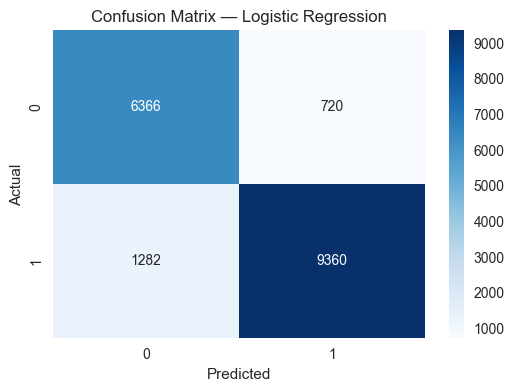

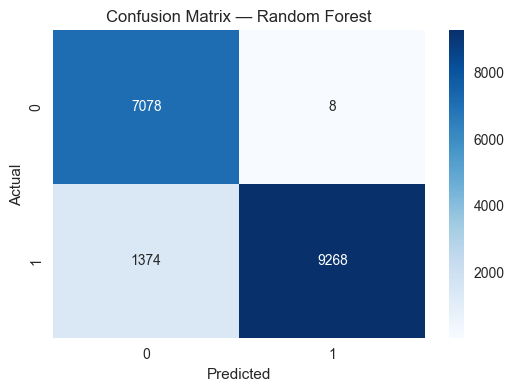

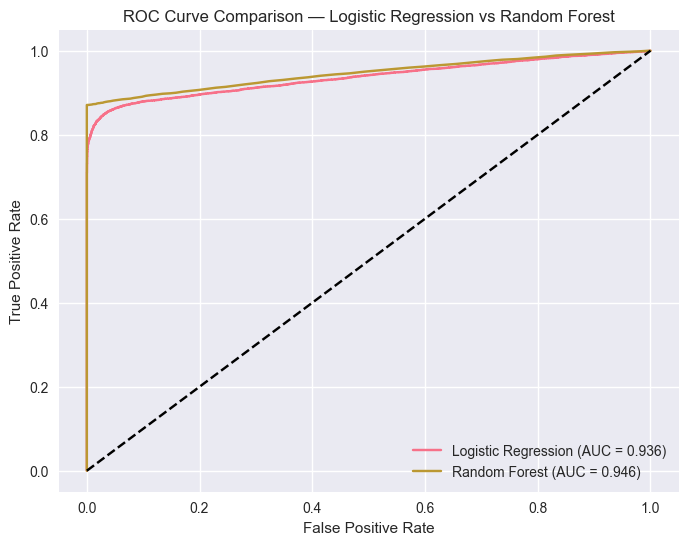

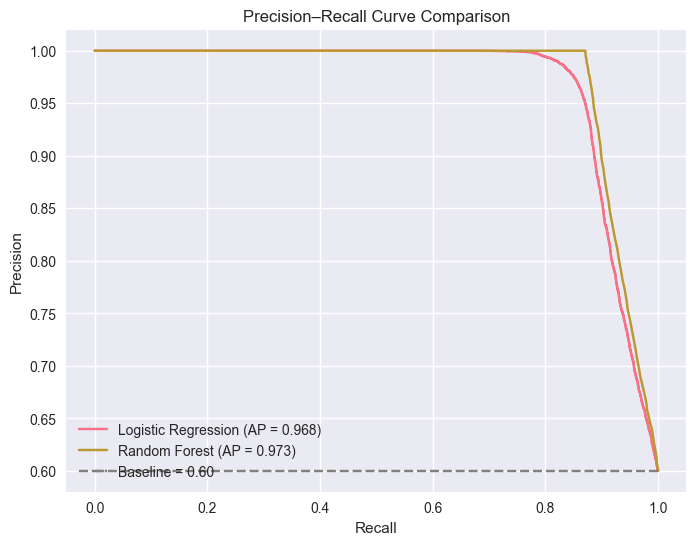

In [26]:
# === Baseline Model 1: Logistic Regression ===

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs"
)

# Train on scaled features
log_reg.fit(X_train_scaled, y_train)

# Predictions on test set
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression Results ===")
print("Accuracy: ", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:   ", recall_score(y_test, y_pred_lr))
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba_lr))

print("\nClassification report:\n", classification_report(y_test, y_pred_lr))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_lr))

# === Baseline Model 2: Random Forest ===

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)

# Train on unscaled features
rf.fit(X_train, y_train)

# Predictions on test set
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest Results ===")
print("Accuracy: ", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:   ", recall_score(y_test, y_pred_rf))
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba_rf))

print("\nClassification report:\n", classification_report(y_test, y_pred_rf))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_rf))

# === Comparison of Baselines ===

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)

# Train on unscaled features
rf.fit(X_train, y_train)

# Predictions on test set
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest Results ===")
print("Accuracy: ", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:   ", recall_score(y_test, y_pred_rf))
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba_rf))

print("\nClassification report:\n", classification_report(y_test, y_pred_rf))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_rf))

#HEATMAP GENERATIONS for Logistic Regression Baseline and Random Forrest Baseline

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Function to plot confusion matrix heatmaps
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Logistic Regression confusion matrix
plot_confusion_matrix(y_test, y_pred_lr, "Confusion Matrix — Logistic Regression")

# Random Forest confusion matrix
plot_confusion_matrix(y_test, y_pred_rf, "Confusion Matrix — Random Forest")

# ROC Curves for Logistic Regression vs Random Forest

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.3f})")

plt.plot([0,1], [0,1], 'k--')  # diagonal baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — Logistic Regression vs Random Forest")
plt.legend()
plt.grid(True)
plt.show()

# === Precision-Recall Curve Comparison (Logistic Regression vs Random Forest) ===

from sklearn.metrics import precision_recall_curve, average_precision_score

# Logistic Regression PR values
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_proba_lr)
ap_lr = average_precision_score(y_test, y_proba_lr)

# Random Forest PR values
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_proba_rf)
ap_rf = average_precision_score(y_test, y_proba_rf)

plt.figure(figsize=(8,6))

# Plot curves
plt.plot(recall_lr, precision_lr, label=f"Logistic Regression (AP = {ap_lr:.3f})")
plt.plot(recall_rf, precision_rf, label=f"Random Forest (AP = {ap_rf:.3f})")

# Baseline (mean positives)
baseline = y_test.mean()
plt.hlines(baseline, 0, 1, colors='gray', linestyles='--', label=f"Baseline = {baseline:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

(62045, 35) (13296, 35) (13296, 35)
Logistic Regression AUC: 0.9377357051106805
Random Forest AUC: 0.9455497323814865
Initial XGBoost AUC: 0.9424511157820565
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=1.0, gamma=1, learning_rate=0.05, max_depth=4, n_estimators=400, reg_alpha=0, reg_lambda=1, subsample=0.6; total time=   1.4s
[CV] END colsample_bytree=1.0, gamma=1, learning_rate=0.05, max_depth=4, n_estimators=400, reg_alpha=0, reg_lambda=1, subsample=0.6; total time=   1.4s
[CV] END colsample_bytree=0.5, gamma=5, learning_rate=0.05, max_depth=8, n_estimators=800, reg_alpha=0.1, reg_lambda=5, subsample=1.0; total time=   1.6s
[CV] END colsample_bytree=1.0, gamma=1, learning_rate=0.05, max_depth=4, n_estimators=400, reg_alpha=0, reg_lambda=1, subsample=0.6; total time=   1.7s
[CV] END colsample_bytree=0.5, gamma=5, learning_rate=0.05, max_depth=8, n_estimators=800, reg_alpha=0.1, reg_lambda=5, subsample=1.0; total time=   1.8s
[CV] END colsampl

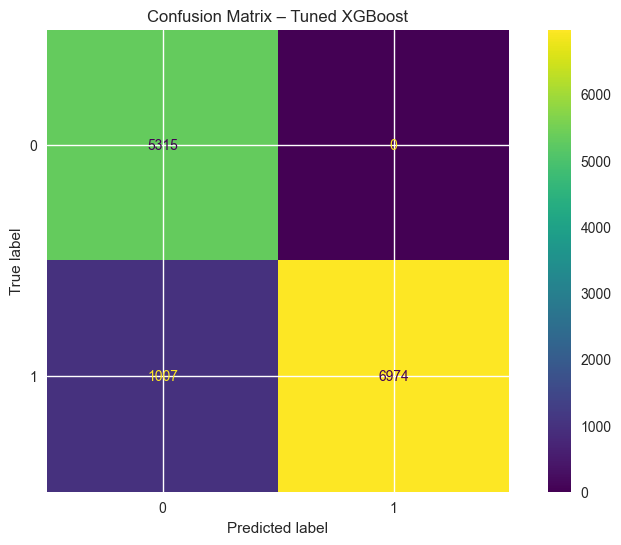

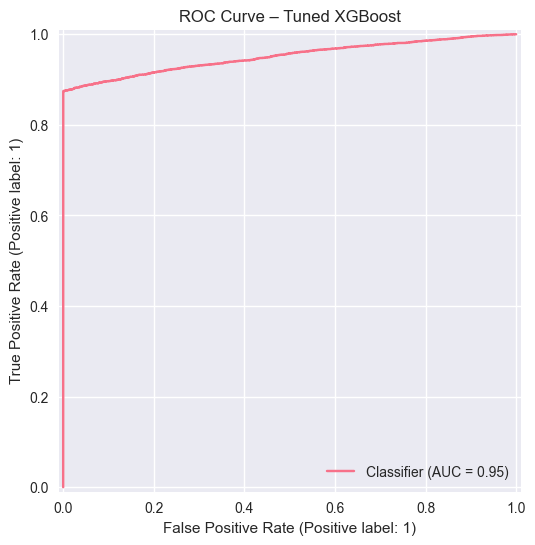

['best_xgb_model.pkl']

In [5]:
from sklearn.model_selection import train_test_split

# Define X and y
X = df_feature.drop("diagnosed_diabetes", axis=1)
y = df_feature["diagnosed_diabetes"]

# Stratified split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(X_train.shape, X_val.shape, X_test.shape)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predictions
log_pred = log_reg.predict(X_val_scaled)
log_auc = roc_auc_score(y_val, log_reg.predict_proba(X_val_scaled)[:,1])

rf_pred = rf.predict(X_val)
rf_auc = roc_auc_score(y_val, rf.predict_proba(X_val)[:,1])

print("Logistic Regression AUC:", log_auc)
print("Random Forest AUC:", rf_auc)

import xgboost as xgb

xgb_basic = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_basic.fit(X_train, y_train)

from sklearn.metrics import roc_auc_score

basic_auc = roc_auc_score(y_val, xgb_basic.predict_proba(X_val)[:,1])
print("Initial XGBoost AUC:", basic_auc)

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [200, 400, 600, 800],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.5, 0.7, 1.0],
    'gamma': [0, 1, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 2, 5]
}

xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)

best_model = random_search.best_estimator_

best_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)


y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:,1]


from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix – Tuned XGBoost")
plt.show()


from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve – Tuned XGBoost")
plt.show()

import joblib
joblib.dump(best_model, "best_xgb_model.pkl")


/var/folders/r1/wbbcp1xn07d110pfbtzrtlj80000gn/T/ipykernel_76914/2556297383.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, show=False)


/var/folders/r1/wbbcp1xn07d110pfbtzrtlj80000gn/T/ipykernel_76914/2556297383.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, show=False)


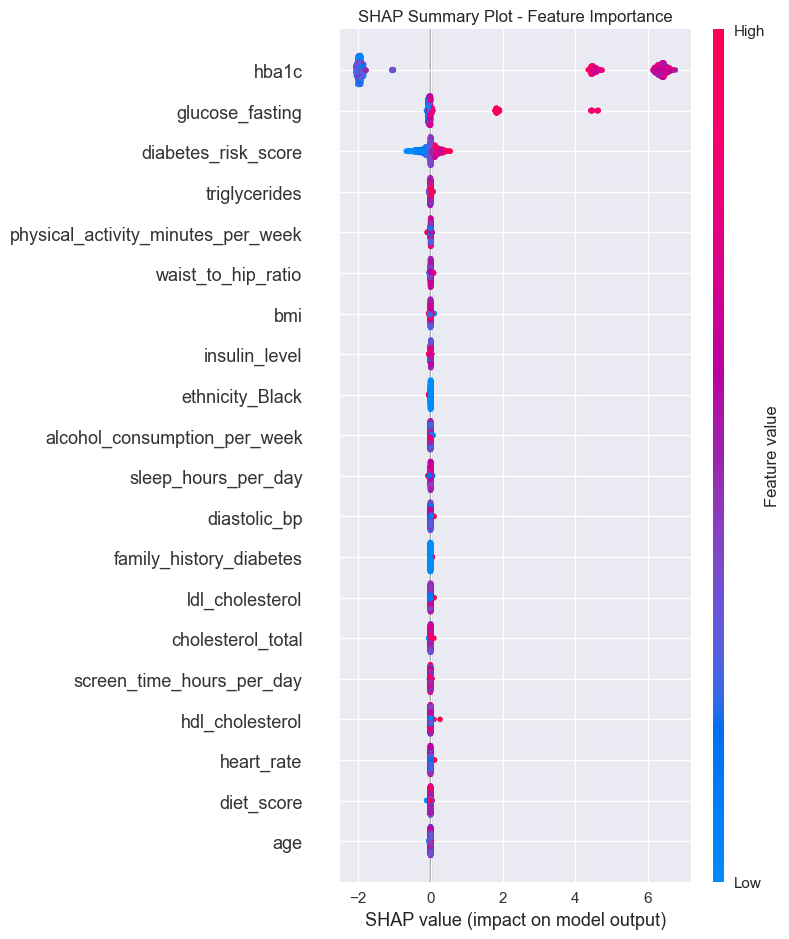

/var/folders/r1/wbbcp1xn07d110pfbtzrtlj80000gn/T/ipykernel_76914/2556297383.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, show=False)


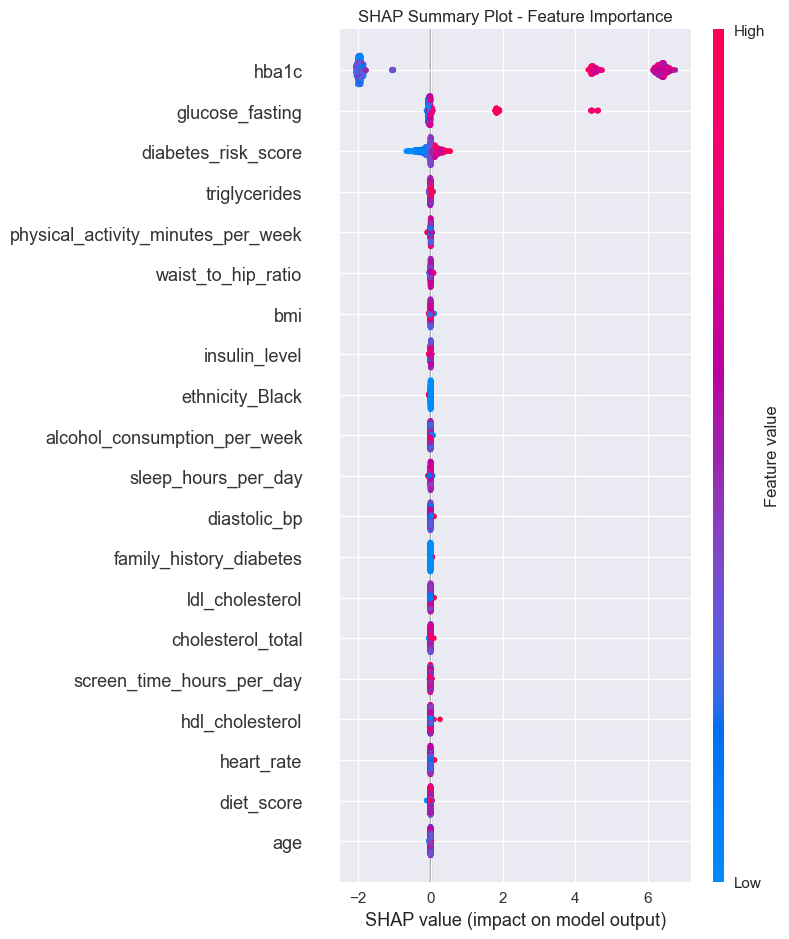

/var/folders/r1/wbbcp1xn07d110pfbtzrtlj80000gn/T/ipykernel_76914/2556297383.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)


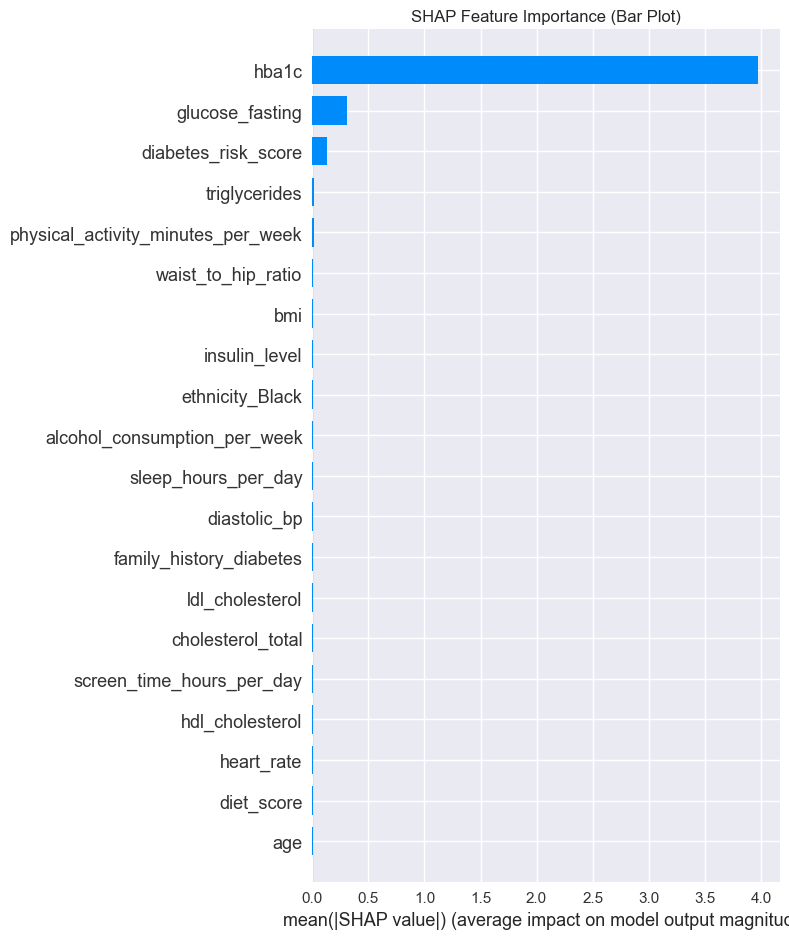

/var/folders/r1/wbbcp1xn07d110pfbtzrtlj80000gn/T/ipykernel_76914/2556297383.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, show=False)


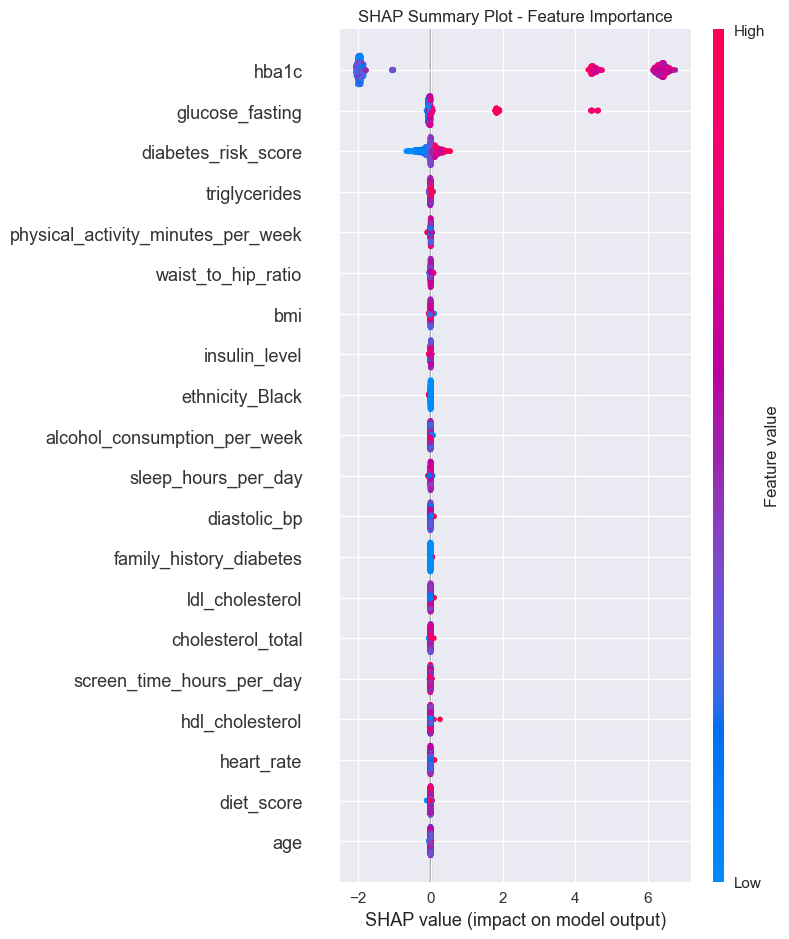

/var/folders/r1/wbbcp1xn07d110pfbtzrtlj80000gn/T/ipykernel_76914/2556297383.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)


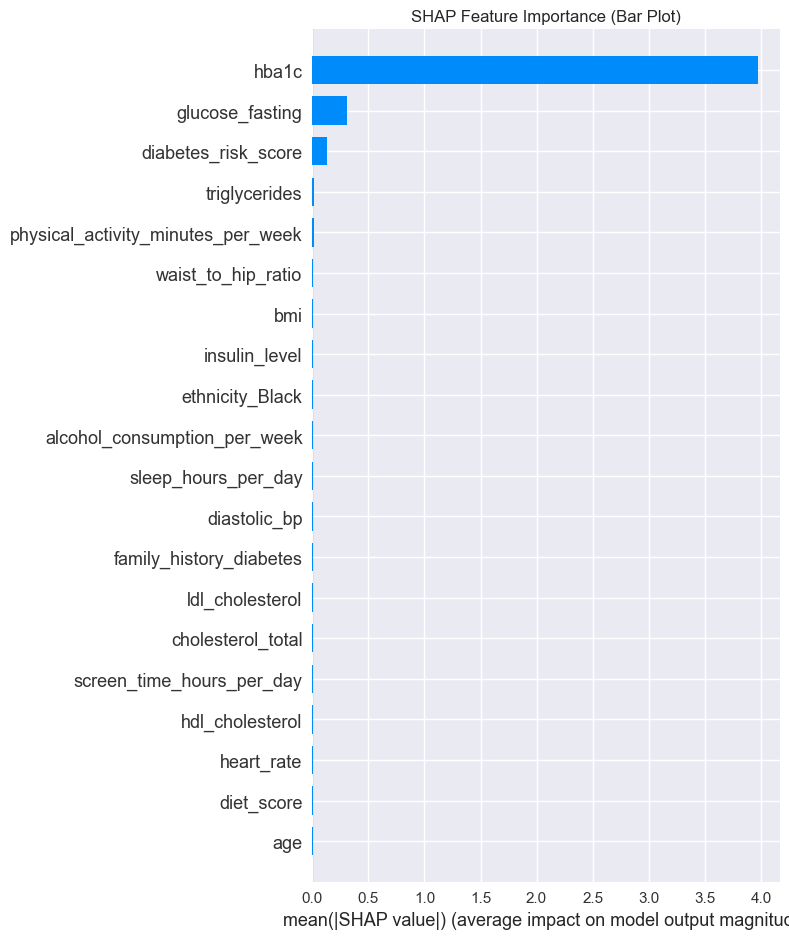

<Figure size 1200x300 with 0 Axes>

/var/folders/r1/wbbcp1xn07d110pfbtzrtlj80000gn/T/ipykernel_76914/2556297383.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, show=False)


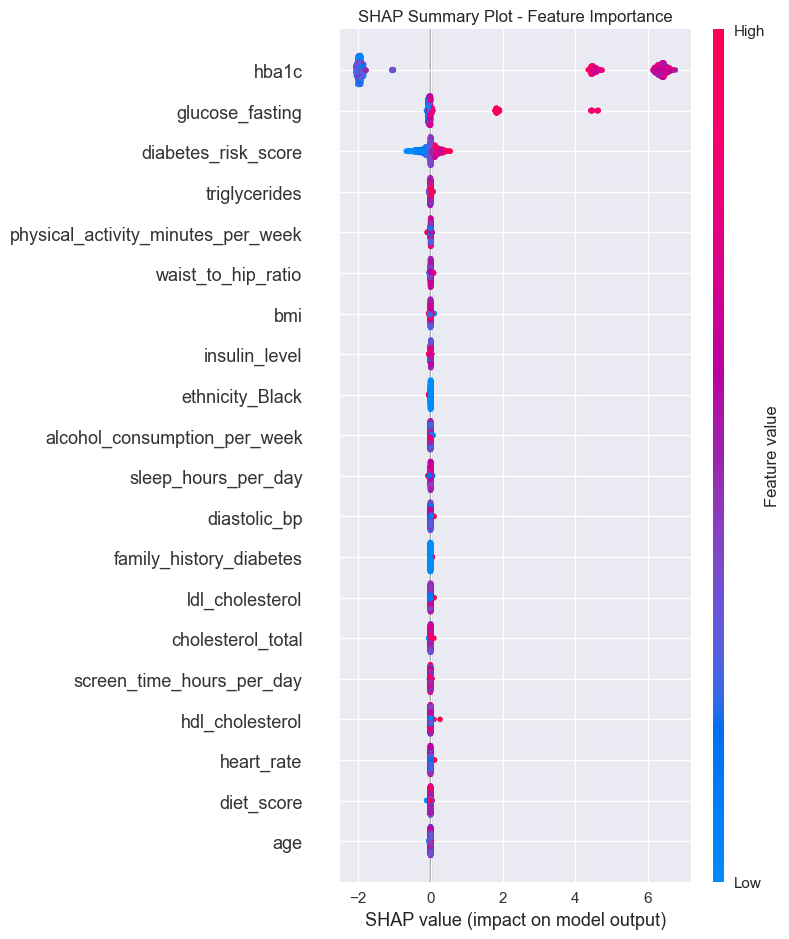

/var/folders/r1/wbbcp1xn07d110pfbtzrtlj80000gn/T/ipykernel_76914/2556297383.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)


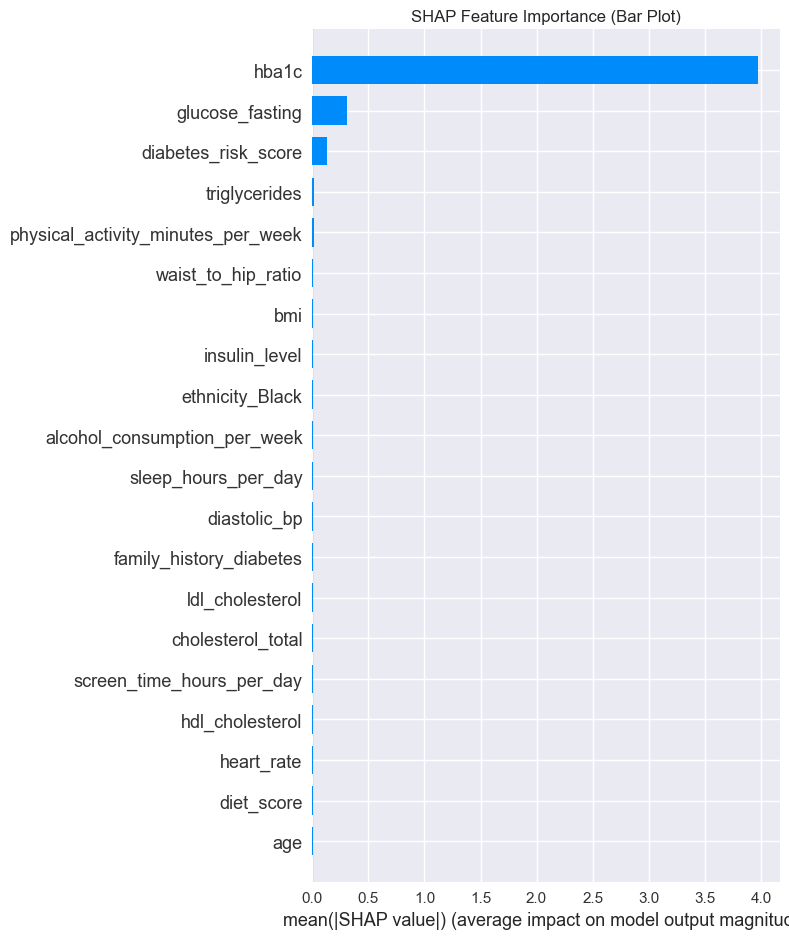

<Figure size 1200x300 with 0 Axes>

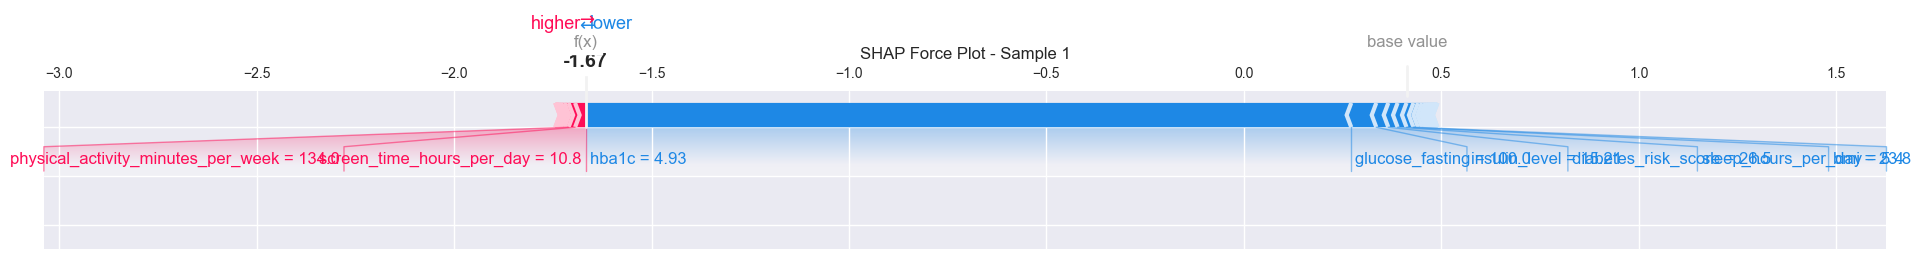

/var/folders/r1/wbbcp1xn07d110pfbtzrtlj80000gn/T/ipykernel_76914/2556297383.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, show=False)


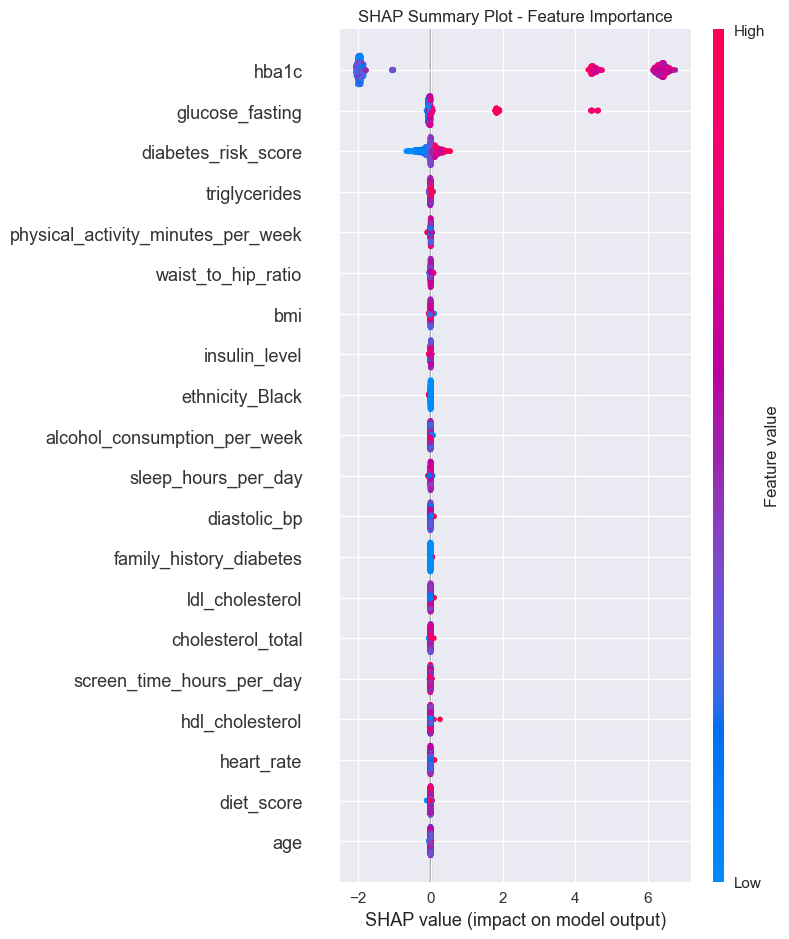

/var/folders/r1/wbbcp1xn07d110pfbtzrtlj80000gn/T/ipykernel_76914/2556297383.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)


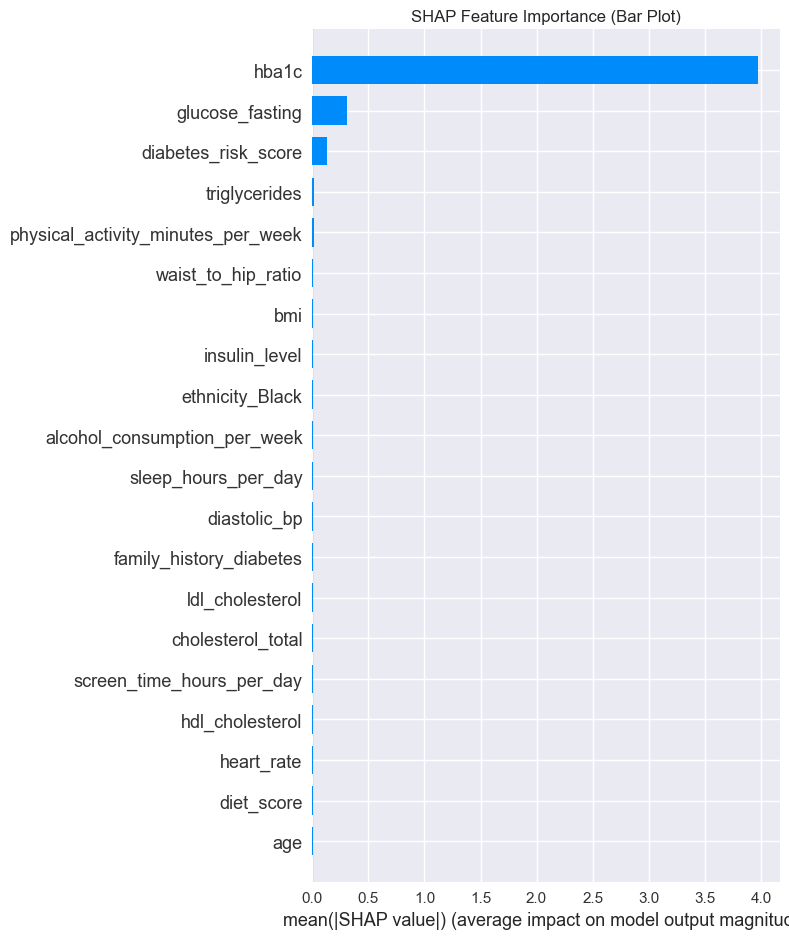

<Figure size 1200x300 with 0 Axes>

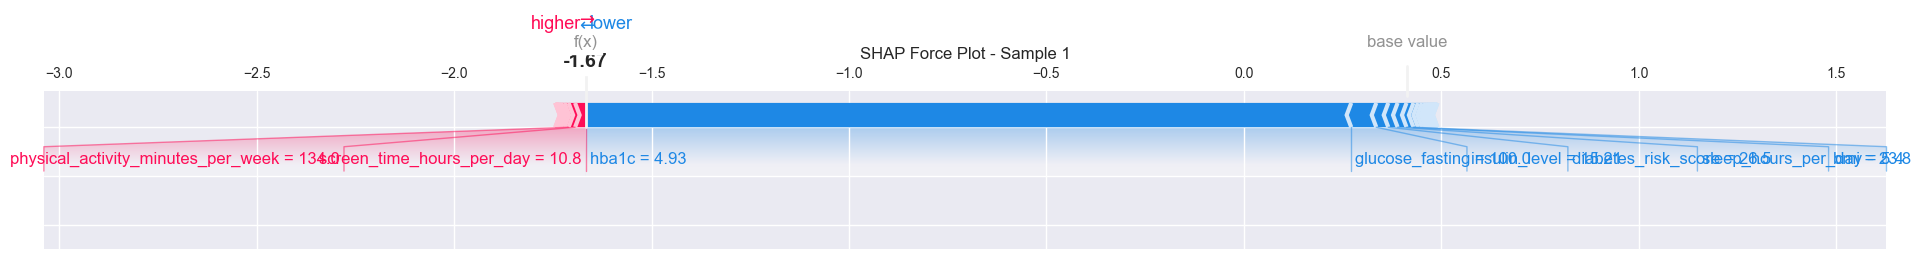

<Figure size 1200x300 with 0 Axes>

/var/folders/r1/wbbcp1xn07d110pfbtzrtlj80000gn/T/ipykernel_76914/2556297383.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, show=False)


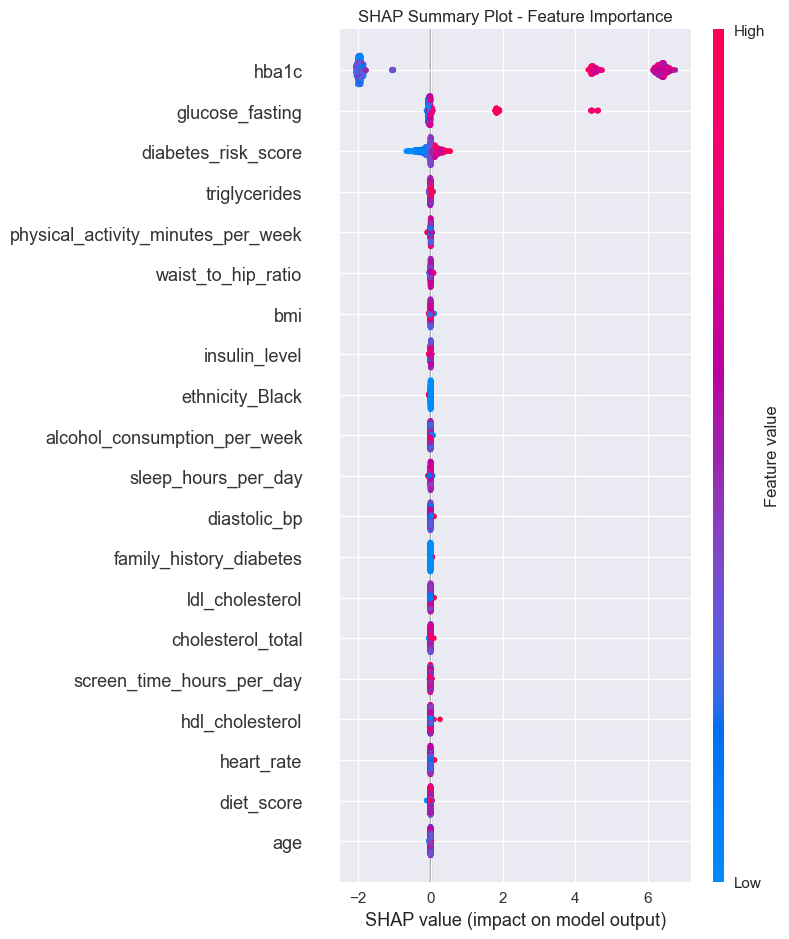

/var/folders/r1/wbbcp1xn07d110pfbtzrtlj80000gn/T/ipykernel_76914/2556297383.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)


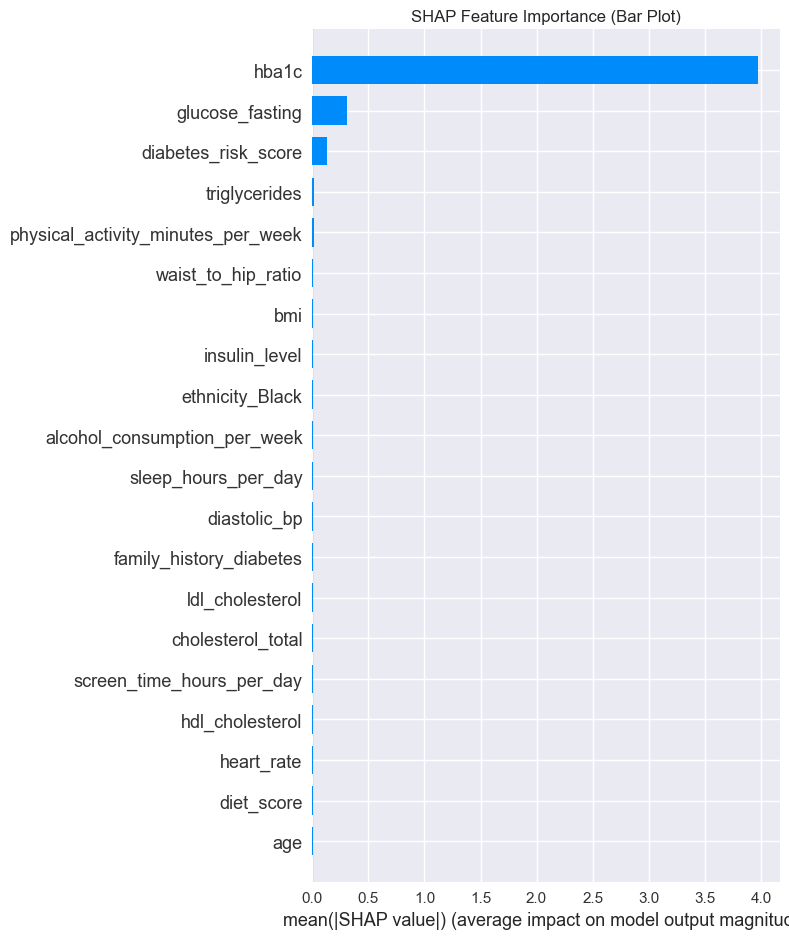

<Figure size 1200x300 with 0 Axes>

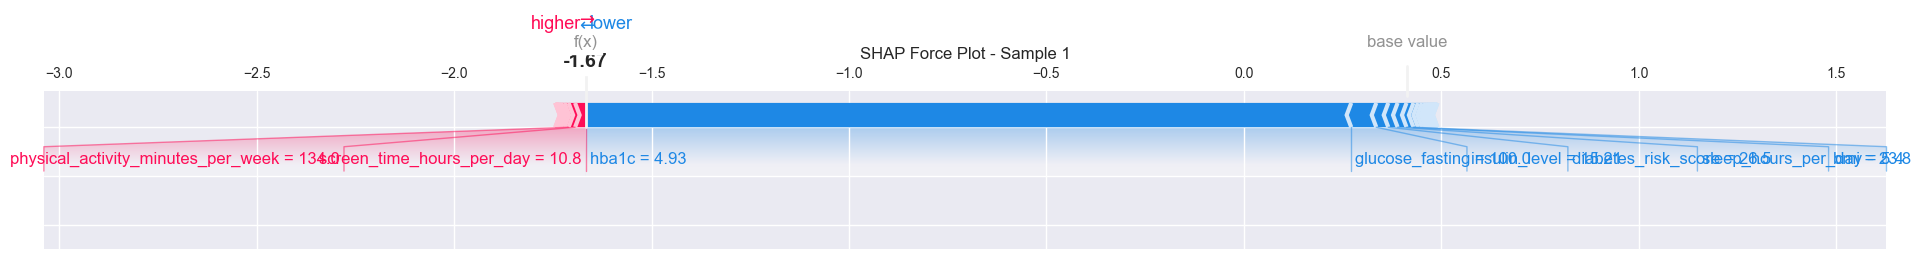

<Figure size 1200x300 with 0 Axes>

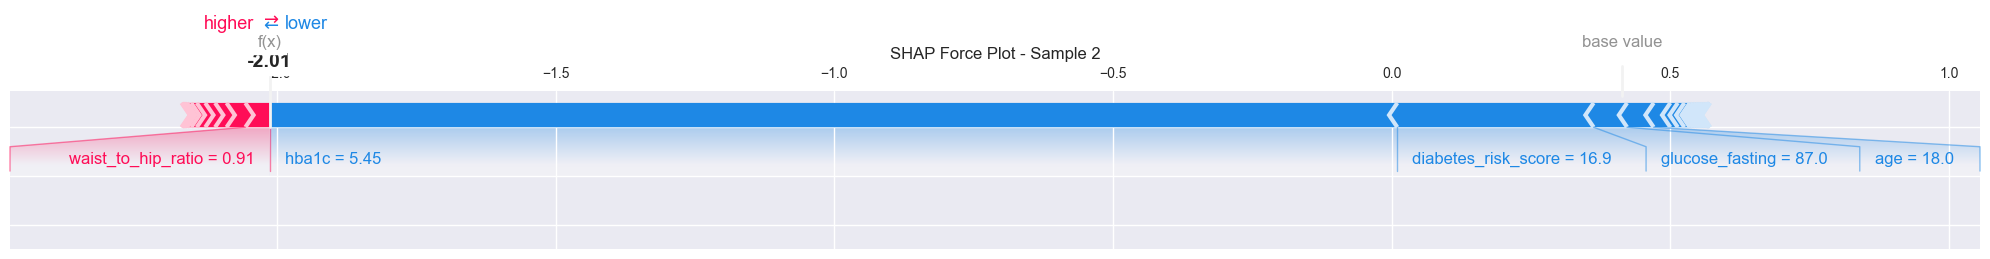

/var/folders/r1/wbbcp1xn07d110pfbtzrtlj80000gn/T/ipykernel_76914/2556297383.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, show=False)


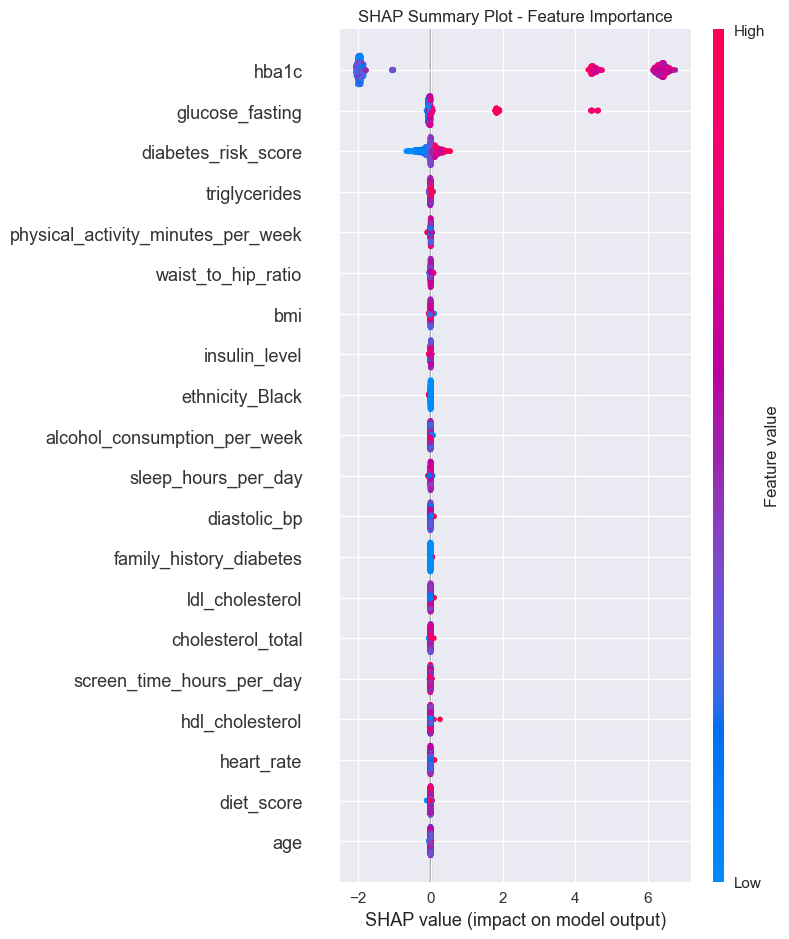

/var/folders/r1/wbbcp1xn07d110pfbtzrtlj80000gn/T/ipykernel_76914/2556297383.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)


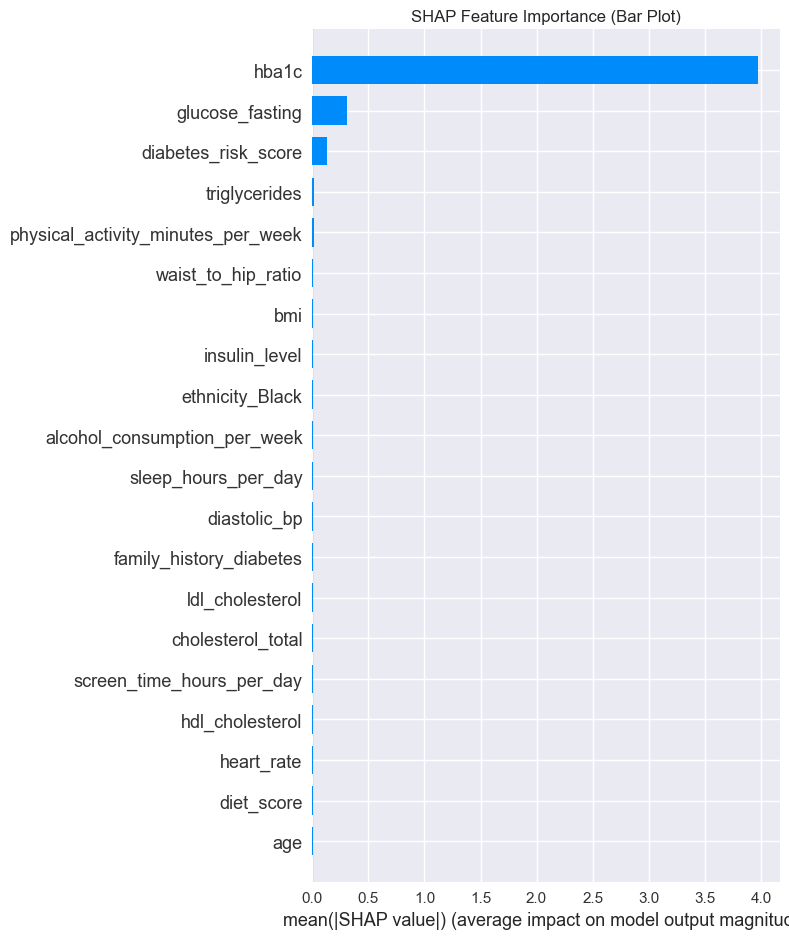

<Figure size 1200x300 with 0 Axes>

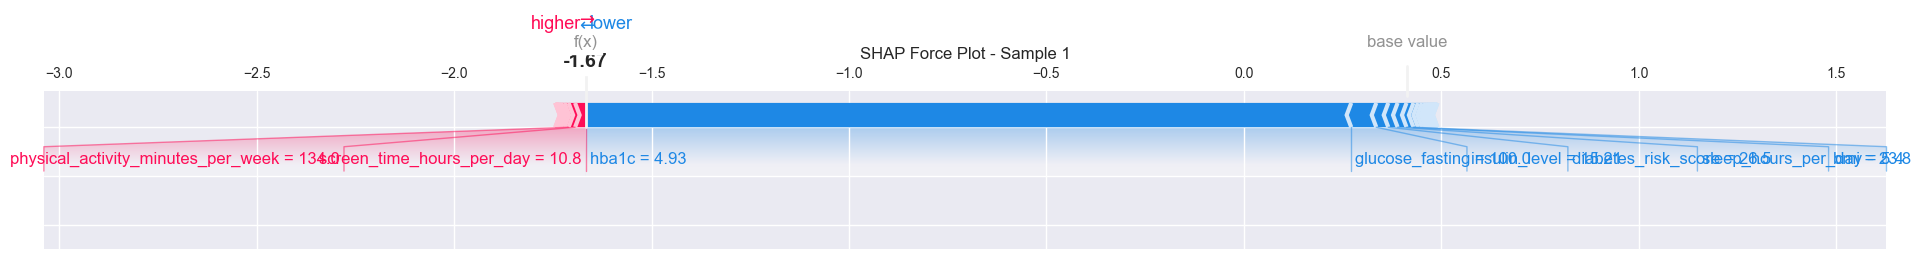

<Figure size 1200x300 with 0 Axes>

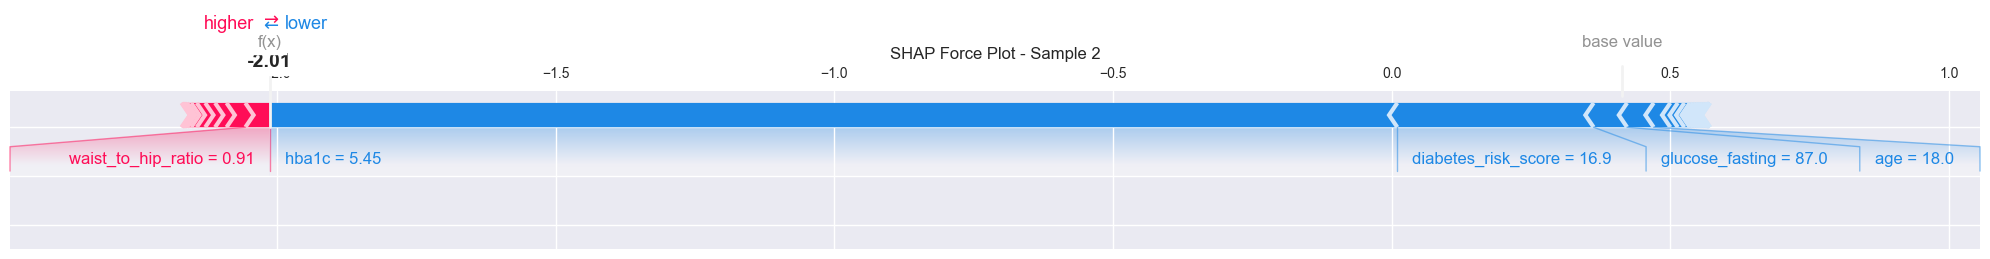

<Figure size 1200x300 with 0 Axes>

/var/folders/r1/wbbcp1xn07d110pfbtzrtlj80000gn/T/ipykernel_76914/2556297383.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, show=False)


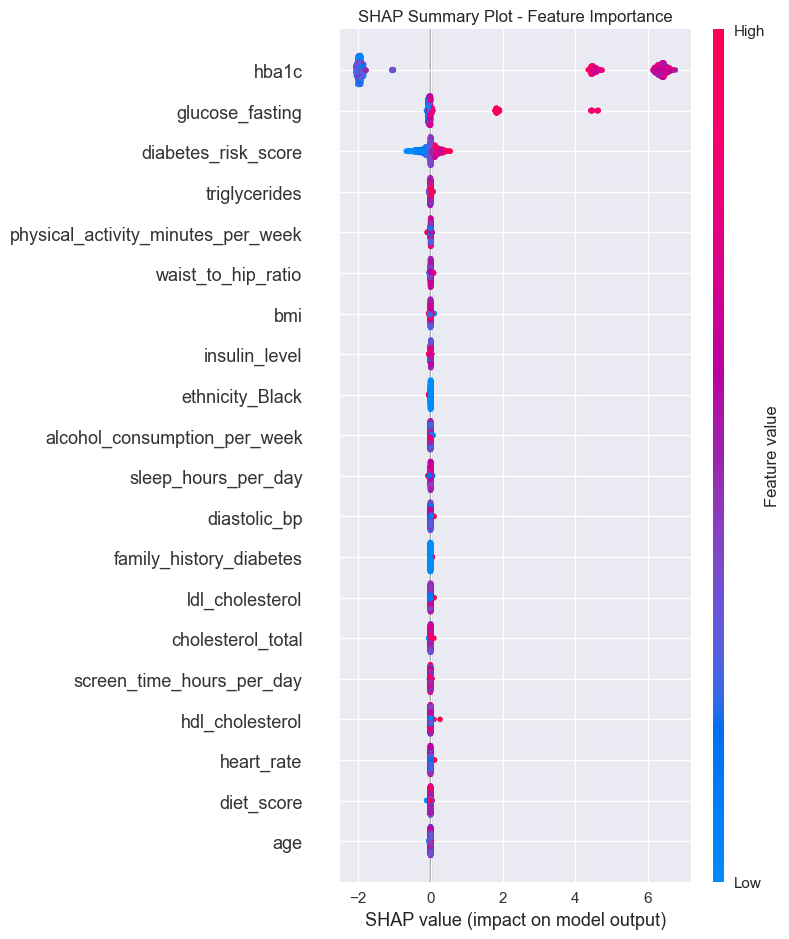

/var/folders/r1/wbbcp1xn07d110pfbtzrtlj80000gn/T/ipykernel_76914/2556297383.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)


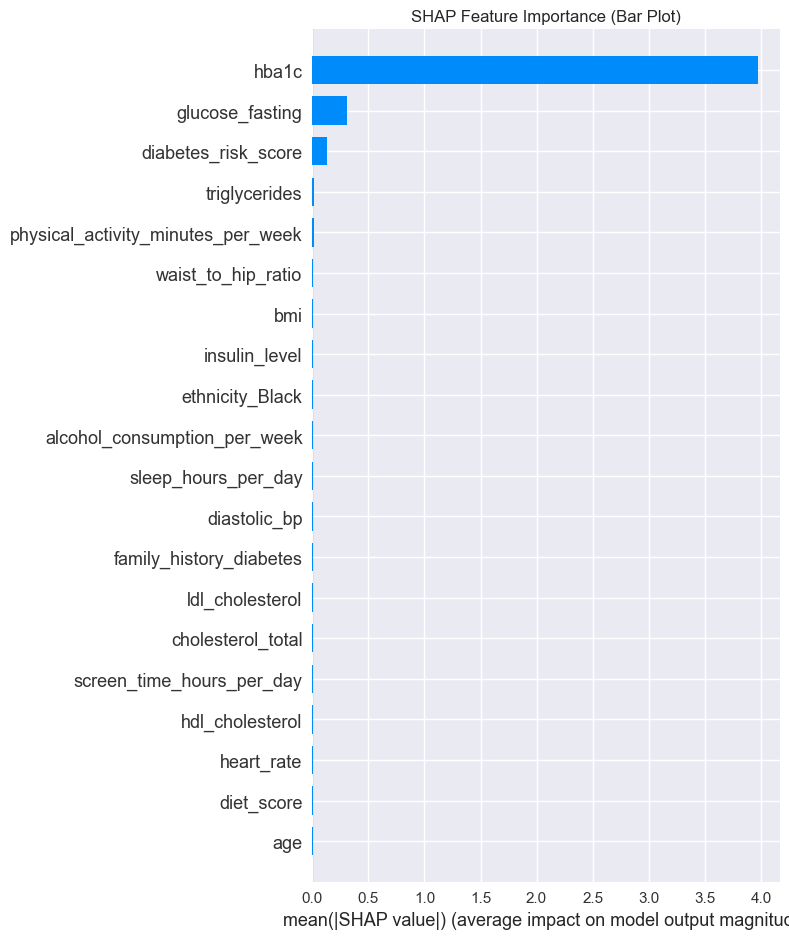

<Figure size 1200x300 with 0 Axes>

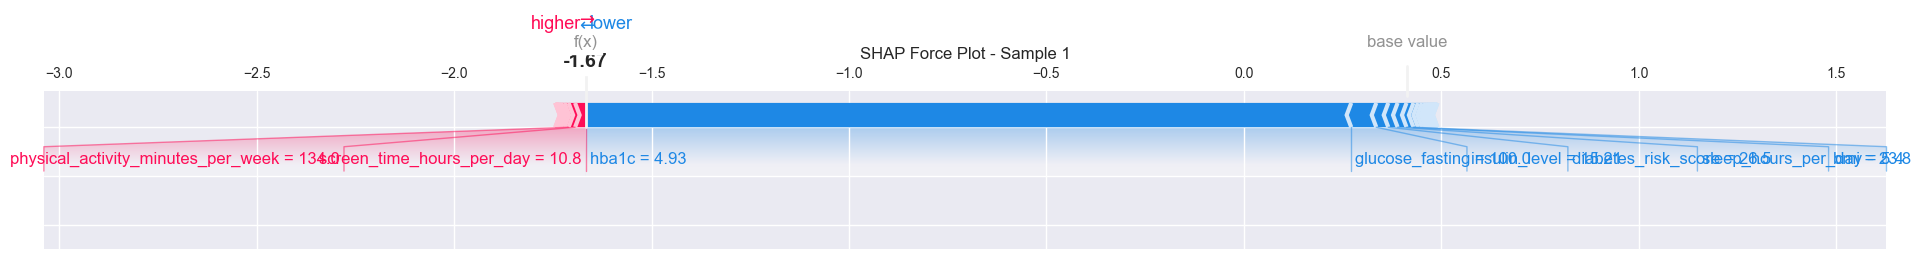

<Figure size 1200x300 with 0 Axes>

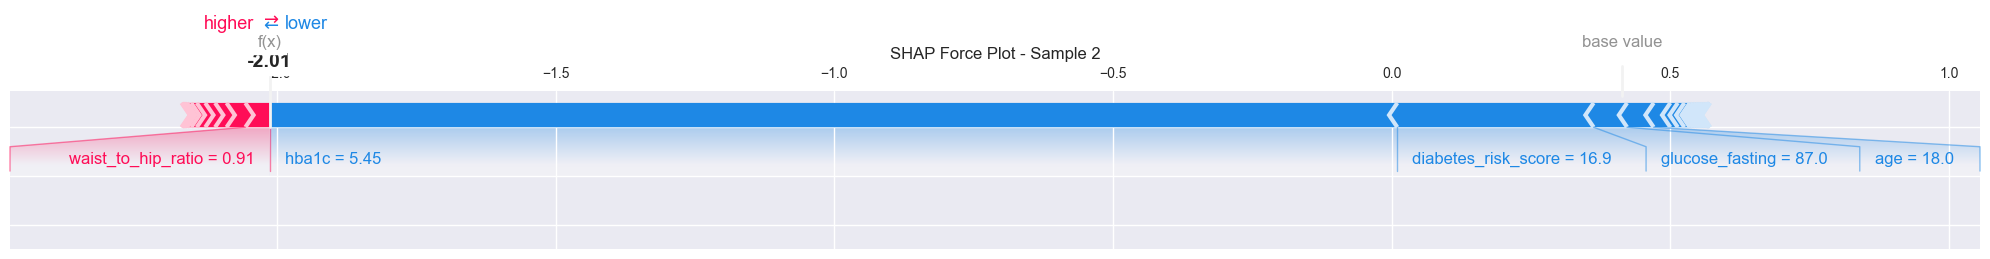

<Figure size 1200x300 with 0 Axes>

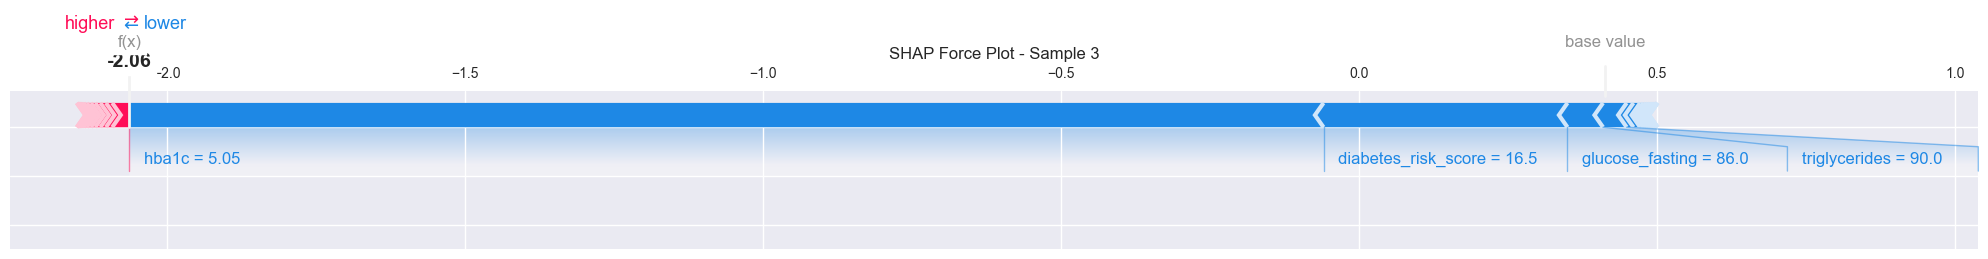

Top 5 Most Influential Features:
25. hba1c: SHAP importance = 3.9719
22. glucose_fasting: SHAP importance = 0.3098
26. diabetes_risk_score: SHAP importance = 0.1347
21. triglycerides: SHAP importance = 0.0128
6. physical_activity_minutes_per_week: SHAP importance = 0.0105

Explanations:
1. hba1c: HbA1c level measures average blood sugar over the past 2-3 months; high values indicate poor glucose control and increased diabetes risk.
2. glucose_fasting: Fasting glucose level is a direct measure of blood sugar after fasting; elevated levels signal diabetes or prediabetes.
3. diabetes_risk_score: A composite score likely incorporating multiple risk factors; higher scores indicate greater overall diabetes risk.
4. triglycerides: Elevated triglyceride levels are associated with metabolic syndrome and increased risk of type 2 diabetes.
5. physical_activity_minutes_per_week: Lower physical activity levels correlate with higher diabetes risk due to reduced insulin sensitivity and weight managem

In [8]:
# === Task 3: SHAP Analysis for Model Interpretability ===

import shap
import matplotlib.pyplot as plt


best_model = joblib.load("best_xgb_model.pkl")

# Use TreeExplainer for XGBoost
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values for the test set (or a subset for speed)
X_test_sample = X_test.sample(n=1000, random_state=42)  # Sample for faster computation
shap_values = explainer.shap_values(X_test_sample)

# SHAP Summary Plot (beeswarm plot showing feature importance and impact)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title("SHAP Summary Plot - Feature Importance")
plt.tight_layout()
plt.show()

# SHAP Bar Plot for top features
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Bar Plot)")
plt.tight_layout()
plt.show()

# SHAP Force Plots for individual predictions (first 3 samples)
for i in range(3):
    plt.figure(figsize=(12, 3))
    shap.force_plot(explainer.expected_value, shap_values[i], X_test_sample.iloc[i], matplotlib=True, show=False)
    plt.title(f"SHAP Force Plot - Sample {i+1}")
    plt.tight_layout()
    plt.show()

# Top 5 influential features explanation
feature_importance = pd.DataFrame({
    'feature': X_test_sample.columns,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values(by='importance', ascending=False)

print("Top 5 Most Influential Features:")
for idx, row in feature_importance.head(5).iterrows():
    print(f"{idx+1}. {row['feature']}: SHAP importance = {row['importance']:.4f}")

# Short explanations for top 5 features
print("\nExplanations:")
print("1. hba1c: HbA1c level measures average blood sugar over the past 2-3 months; high values indicate poor glucose control and increased diabetes risk.")
print("2. glucose_fasting: Fasting glucose level is a direct measure of blood sugar after fasting; elevated levels signal diabetes or prediabetes.")
print("3. diabetes_risk_score: A composite score likely incorporating multiple risk factors; higher scores indicate greater overall diabetes risk.")
print("4. triglycerides: Elevated triglyceride levels are associated with metabolic syndrome and increased risk of type 2 diabetes.")
print("5. physical_activity_minutes_per_week: Lower physical activity levels correlate with higher diabetes risk due to reduced insulin sensitivity and weight management.")

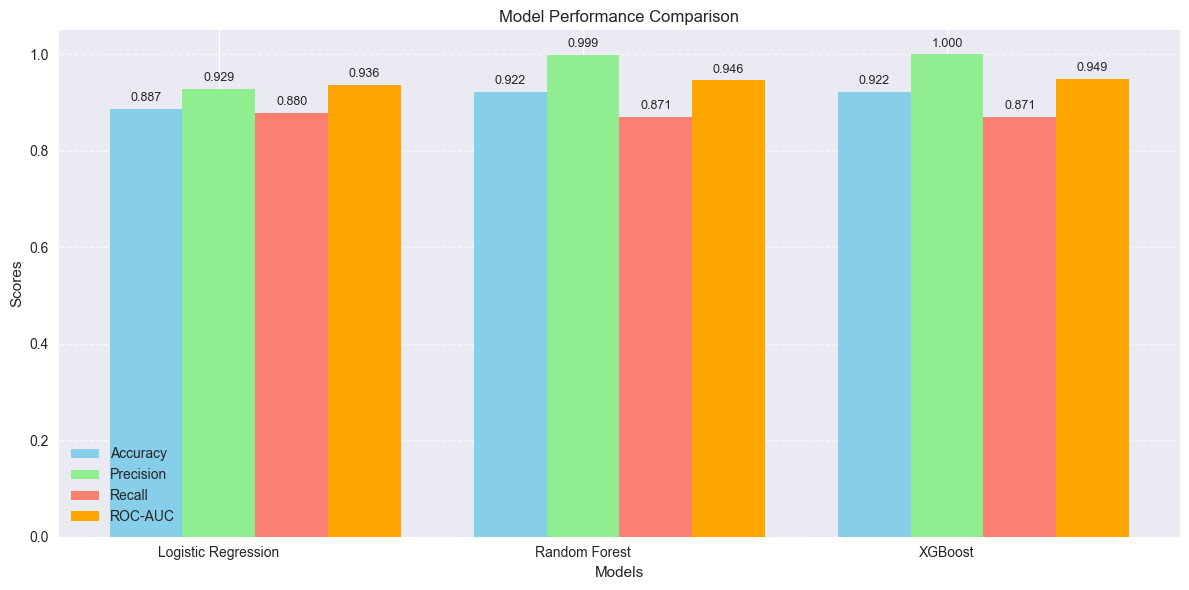

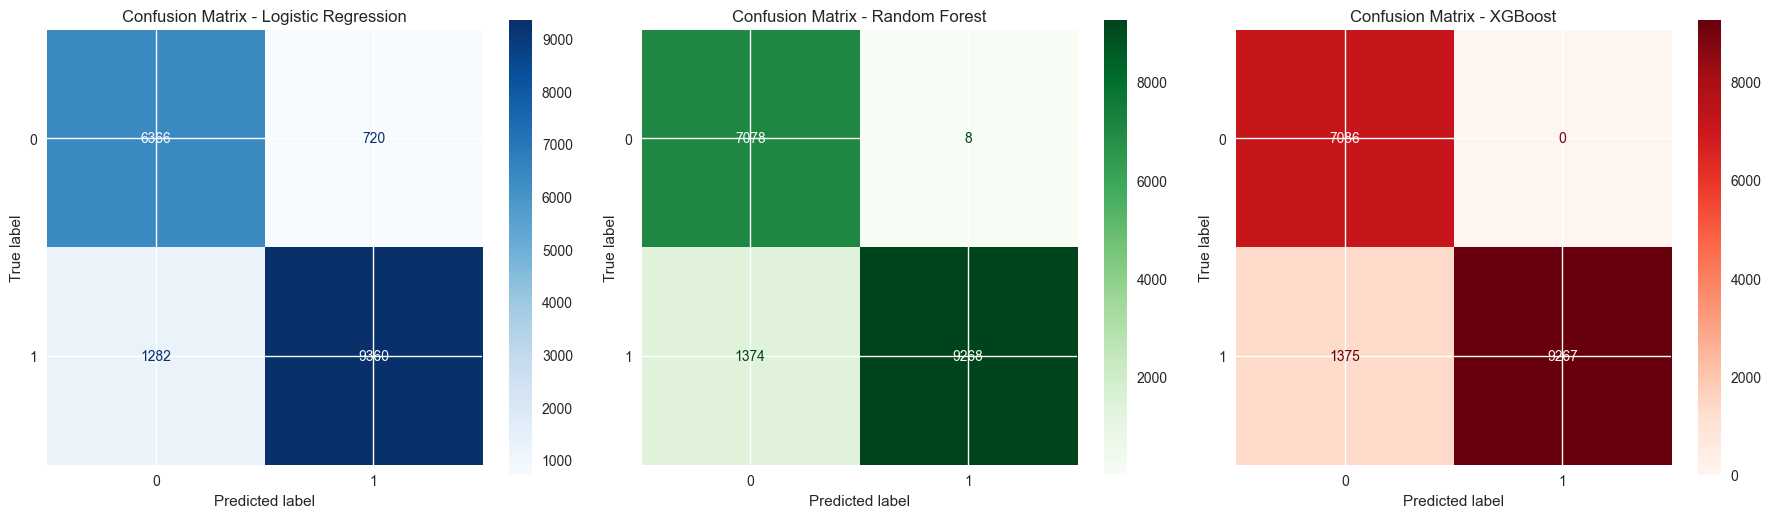

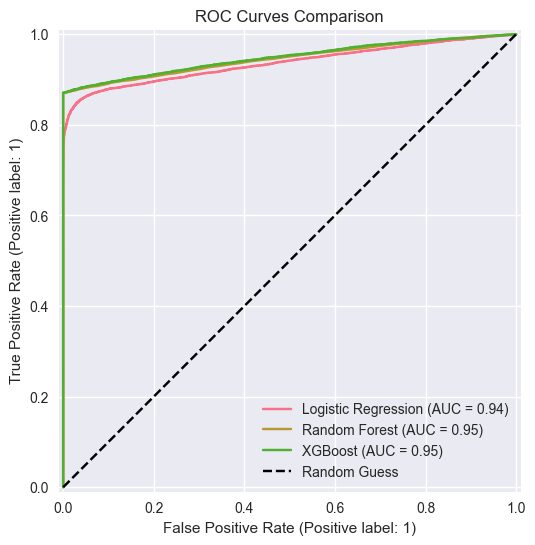

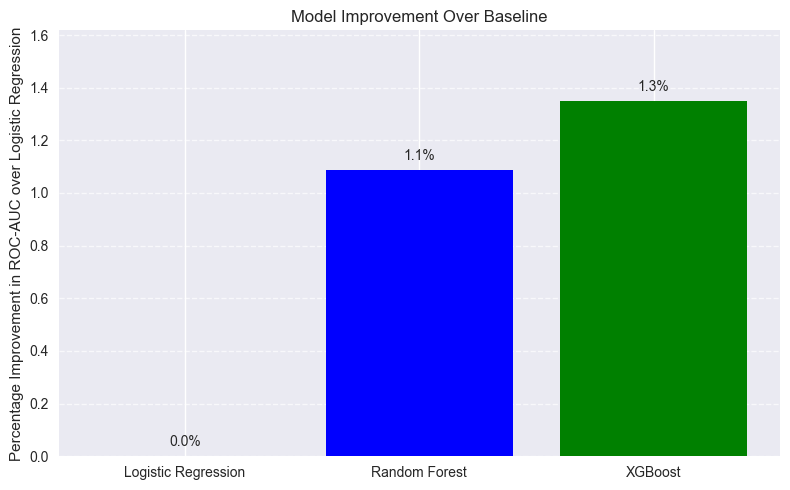

=== Model Performance Summary ===
Logistic Regression:
  Accuracy: 0.887
  Precision: 0.929
  Recall: 0.880
  AUC: 0.936

Random Forest:
  Accuracy: 0.922
  Precision: 0.999
  Recall: 0.871
  AUC: 0.946

XGBoost:
  Accuracy: 0.922
  Precision: 1.000
  Recall: 0.871
  AUC: 0.949

=== Improvements Over Logistic Regression Baseline ===
Random Forest: 1.1% improvement in AUC
XGBoost: 1.3% improvement in AUC


In [31]:
# === Task 3: Performance Visuals - Model Comparison ===

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

# Retrain baseline models on the same split as XGBoost for fair comparison
log_reg_final = LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs")
log_reg_final.fit(X_train_scaled, y_train)

rf_final = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced_subsample", n_jobs=-1)
rf_final.fit(X_train, y_train)

# Get predictions for all models on the same test set
lr_pred_test = log_reg_final.predict(X_test_scaled)
lr_proba_test = log_reg_final.predict_proba(X_test_scaled)[:, 1]

rf_pred_test = rf_final.predict(X_test)
rf_proba_test = rf_final.predict_proba(X_test)[:, 1]

# XGBoost predictions (recompute to ensure consistency)
xgb_pred_test = best_model.predict(X_test)
xgb_proba_test = best_model.predict_proba(X_test)[:, 1]

# Compute metrics for all models
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracies = [
   accuracy_score(y_test, lr_pred_test),
   accuracy_score(y_test, rf_pred_test),
   accuracy_score(y_test, xgb_pred_test)
]
precisions = [
   precision_score(y_test, lr_pred_test),
   precision_score(y_test, rf_pred_test),
   precision_score(y_test, xgb_pred_test)
]
recalls = [
   recall_score(y_test, lr_pred_test),
   recall_score(y_test, rf_pred_test),
   recall_score(y_test, xgb_pred_test)
]
aucs = [
   roc_auc_score(y_test, lr_proba_test),
   roc_auc_score(y_test, rf_proba_test),
   roc_auc_score(y_test, xgb_proba_test)
]

# Bar chart comparison
x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, accuracies, width, label='Accuracy', color='skyblue')
bars2 = ax.bar(x, precisions, width, label='Precision', color='lightgreen')
bars3 = ax.bar(x + width, recalls, width, label='Recall', color='salmon')
bars4 = ax.bar(x + 2*width, aucs, width, label='ROC-AUC', color='orange')

ax.set_xlabel('Models')
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on bars
def add_labels(bars):
   for bar in bars:
       height = bar.get_height()
       ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
               f'{height:.3f}', ha='center', va='bottom', fontsize=9)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)
add_labels(bars4)

plt.tight_layout()
plt.show()

# Confusion Matrices for all models
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(y_test, lr_pred_test, ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix - Logistic Regression')

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred_test, ax=axes[1], cmap='Greens')
axes[1].set_title('Confusion Matrix - Random Forest')

ConfusionMatrixDisplay.from_predictions(y_test, xgb_pred_test, ax=axes[2], cmap='Reds')
axes[2].set_title('Confusion Matrix - XGBoost')

plt.tight_layout()
plt.show()

# ROC Curves Comparison
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, lr_proba_test, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_predictions(y_test, rf_proba_test, ax=ax, name='Random Forest')
RocCurveDisplay.from_predictions(y_test, xgb_proba_test, ax=ax, name='XGBoost')

ax.plot([0, 1], [0, 1], 'k--', label='Random Guess')
ax.set_title('ROC Curves Comparison')
ax.legend()
ax.grid(True)
plt.show()

# Model Improvement Visualization (over baseline LR)
baseline_auc = aucs[0]
improvements = [(auc - baseline_auc) / baseline_auc * 100 for auc in aucs]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, improvements, color=['red', 'blue', 'green'])
ax.set_ylabel('Percentage Improvement in ROC-AUC over Logistic Regression')
ax.set_title('Model Improvement Over Baseline')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Set y-axis limits to better show the small improvements
max_imp = max(improvements)
ax.set_ylim(0, max_imp * 1.2)  # Set upper limit to 120% of max improvement

for bar, imp in zip(bars, improvements):
   ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max_imp * 0.02),
           f'{imp:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Summary statistics
print("=== Model Performance Summary ===")
for i, model in enumerate(models):
    print(f"{model}:")
    print(f"  Accuracy: {accuracies[i]:.3f}")
    print(f"  Precision: {precisions[i]:.3f}")
    print(f"  Recall: {recalls[i]:.3f}")
    print(f"  AUC: {aucs[i]:.3f}")
    print()

print("=== Improvements Over Logistic Regression Baseline ===")
for i, model in enumerate(models):
    if i > 0:
        print(f"{model}: {improvements[i]:.1f}% improvement in AUC")